# exp-h0-complement-nb-profile-blend-01

## Goal

Complement NB가 안전 H0 Selective-EB LR + 자동 LGBM specialist와 다른 mutation-profile 오류를 보완하는지 확인합니다.

- 고정 확률: `0.80 × H0 + 0.20 × Complement NB`
- NB: binary mutation profile, `alpha=1.0`, `norm=True`
- seed42 OOF에서는 train만 읽고 test를 읽지 않습니다.
- 모든 vocabulary, EB, recurrent event, specialist, NB fit은 outer-fold train only입니다.
- 고정 암종명·유전자명·exact mutation 목록을 사용하지 않습니다.
- WT/blank/NaN은 event 0개이며 `nan_as_mutation_count=0`을 검증합니다.

승격 기준: H0 대비 `+0.003` 이상, 5개 fold 중 4개 이상 상승.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
EXP_DIR = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_009'
RUNNER = EXP_DIR / 'common' / 'run_h0_complement_nb_profile_blend.py'
RESULT = EXP_DIR / 'result'
RUN_ID = 'exp-h0-complement-nb-profile-blend-01'
SEEDS = (42,)
RUN_EXPERIMENT = True
assert RUNNER.exists() and (ROOT / 'data/raw/train.csv').exists()
print({'runner': RUNNER, 'result': RESULT, 'seeds': SEEDS, 'test_read_in_oof': False})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_009/common/run_h0_complement_nb_profile_blend.py'), 'result': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_009/result'), 'seeds': (42,), 'test_read_in_oof': False}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 체크포인트가 있으므로 재실행 시 완료 fold를 다시 학습하지 않습니다.
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seeds', *map(str, SEEDS)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H0 + Complement NB folds', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('H0 + Complement NB runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: existing result files only.')

H0 + Complement NB folds: 1line [00:05,  5.19s/line]

[H0+NB] seed 42, fold 1/5: H0 and train-only profile NB


H0 + Complement NB folds: 2line [04:20, 152.58s/line]

[H0+NB] seed 42, fold 1/5 checkpoint saved
[H0+NB] seed 42, fold 2/5: H0 and train-only profile NB


H0 + Complement NB folds: 4line [08:53, 142.48s/line]

...

H0 + Complement NB folds: 10line [22:44, 144.68s/line]

[H0+NB] seed 42, fold 5/5 checkpoint saved


H0 + Complement NB folds: 11line [22:45, 110.85s/line]

{"test_read": false, "raw_train_test_concat": false, "fixed_class_gene_exact_mutation_rules": false, "outer_validation_used_for_fit": false, "leakage_check": true, "nan_as_mutation_count": 0, "h0_weight": 0.8, "nb_weight": 0.2, "nb_alpha": 1.0, "run_id": "exp-h0-complement-nb-profile-blend-01", "seed": 42, "h0_macro_f1": 0.5479146612629726, "blend_macro_f1": 0.5479146612629726, "screen_delta": 0.0, "positive_fold_count": 0, "screen_candidate": false}


H0 + Complement NB folds: 11line [22:45, 124.18s/line]


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
audit = pd.read_json(RESULT / f'{RUN_ID}_seed42_leakage_audit.json', typ='series')
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('oof_macro_f1', ascending=False))
display(audit)

,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,42,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,1359.415184,0.000000
2,42,H0_plus_Complement_NB,0.547915,0.558942,12447.8,0,True,0,1359.462013,0.000000
1,42,Complement_NB,0.197222,0.251734,4228.6,0,True,0,1359.438848,-0.350693


test_read                                                                False
raw_train_test_concat                                                    False
fixed_class_gene_exact_mutation_rules                                    False
outer_validation_used_for_fit                                            False
leakage_check                                                             True
nan_as_mutation_count                                                        0
h0_weight                                                                  0.8
nb_weight                                                                  0.2
nb_alpha                                                                   1.0
run_id                                   exp-h0-complement-nb-profile-blend-01
seed                                                                        42
h0_macro_f1                                                           0.547915
blend_macro_f1                                      

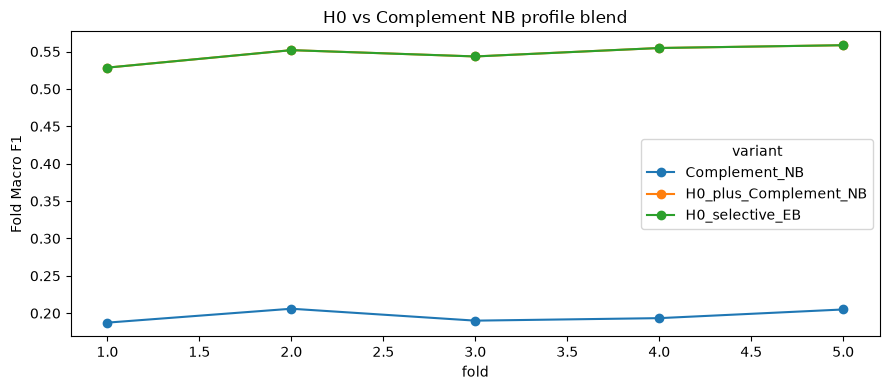

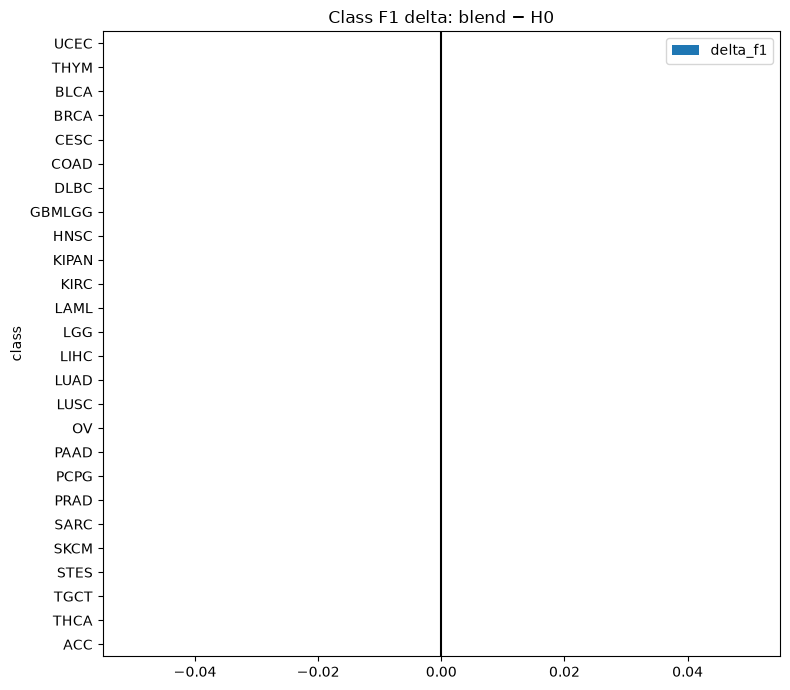

In [4]:
pivot = folds.pivot(index='fold', columns='variant', values='macro_f1')
pivot.plot(marker='o', figsize=(9, 4), title='H0 vs Complement NB profile blend')
plt.ylabel('Fold Macro F1'); plt.tight_layout(); plt.show()
classes.sort_values('delta_f1').plot.barh(x='class', y='delta_f1', figsize=(8, 7), title='Class F1 delta: blend − H0')
plt.axvline(0, color='black'); plt.tight_layout(); plt.show()

In [5]:
h0 = float(summary.loc[summary.variant.eq('H0_selective_EB'), 'oof_macro_f1'].iloc[0])
blend = float(summary.loc[summary.variant.eq('H0_plus_Complement_NB'), 'oof_macro_f1'].iloc[0])
positive_folds = int((pivot['H0_plus_Complement_NB'] > pivot['H0_selective_EB']).sum())
delta = blend - h0
decision = 'screen_candidate' if delta >= 0.003 and positive_folds >= 4 else 'rejected_or_not_detected'
print({'h0': h0, 'blend': blend, 'delta': delta, 'positive_folds': positive_folds, 'decision': decision})
print('screen_candidate일 때만 사전 고정한 42/777/2024 3-seed를 실행합니다.')

{'h0': 0.5479146612629726, 'blend': 0.5479146612629726, 'delta': 0.0, 'positive_folds': 0, 'decision': 'rejected_or_not_detected'}
screen_candidate일 때만 사전 고정한 42/777/2024 3-seed를 실행합니다.
